
# Laboratorio 2 – Complejidad y Búsqueda de Hiperparámetros  
**Curso:** ISIS2611  
**Caso:** AlpesHearth  

**Estudiantes:**  
- Nikol Katherin Rodriguez Ortiz - 202317538
- Nombre 2  



## 1. Introducción

En este laboratorio se evalúan diferentes enfoques de modelado para estimar el riesgo cardiovascular:

- Regresión polinomial  
- Regresión regularizada (Ridge y Lasso)  
- Regresión polinomial regularizada  

Se analiza el impacto de la complejidad en la generalización y se estiman intervalos de confianza mediante bootstrapping.


## 2. Carga de Librerías

In [45]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


## 3. Carga del Dataset

In [46]:
# Cargar el dataset limpio
dataset = pd.read_csv("dataset_limpio.csv")
df =dataset.copy()

df.head()



,Patient ID,Date of Service,Sex,Age,Weight (kg),Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,Height (cm),Systolic BP,Diastolic BP,CVD Risk Score
0,QgsB2968,01 Aug 20,M,40,56.0,84.20,155.0,53.0,104.0,N,N,Moderate,Y,185.000,144.0,85.0,13.600
1,GcaU3177,01 Aug 24,M,63,55.0,103.18,252.0,42.0,147.0,N,N,Low,Y,174.204,101.0,77.0,15.069
2,ywdP2642,01 Jan 22,F,58,98.0,74.60,281.0,68.0,126.0,N,N,Moderate,N,186.000,133.0,83.0,17.910
3,FFib5797,01 Jul 20,M,42,108.0,106.70,186.0,79.0,73.0,N,Y,High,Y,165.000,103.0,82.0,18.770
4,ZzGw2657,01 Jun 23,M,45,62.0,84.10,141.0,45.0,117.0,Y,Y,High,N,180.000,117.0,60.0,14.510


In [47]:


# Copia del dataset
df = df.copy()

# ===============================
# 1. ELIMINAR COLUMNAS INÚTILES
# ===============================
cols_to_drop = [
    'Patient ID',        # ID no aporta info
    'Date of Service'    # Fecha cruda (si no usas features temporales)
]

df = df.drop(columns=cols_to_drop)

# ===============================
# 2. BINARIAS (SI/NO)
# ===============================
binary_cols = [
    'Smoking Status',
    'Diabetes Status',
    'Family History of CVD'
]

for col in binary_cols:
    df[col] = df[col].map({'Y':1, 'N':0})

# ===============================
# 3. SEXO (M/F)
# ===============================
df['Sex'] = df['Sex'].map({'M':1, 'F':0})

# ===============================
# 4. ACTIVIDAD FÍSICA (ORDINAL)
# ===============================
activity_map = {
    'Low':0,
    'Moderate':1,
    'High':2
}
df['Physical Activity Level'] = df['Physical Activity Level'].map(activity_map)

# ===============================
# 5. VERIFICAR RESULTADO
# ===============================
print(df.head())
print("\nShape:", df.shape)
print("\nTipos:")
print(df.dtypes)

   Sex  Age  Weight (kg)  Abdominal Circumference (cm)  \
0    1   40         56.0                         84.20   
1    1   63         55.0                        103.18   
2    0   58         98.0                         74.60   
3    1   42        108.0                        106.70   
4    1   45         62.0                         84.10   

   Total Cholesterol (mg/dL)  HDL (mg/dL)  Fasting Blood Sugar (mg/dL)  \
0                      155.0         53.0                        104.0   
1                      252.0         42.0                        147.0   
2                      281.0         68.0                        126.0   
3                      186.0         79.0                         73.0   
4                      141.0         45.0                        117.0   

   Smoking Status  Diabetes Status  Physical Activity Level  \
0               0                0                        1   
1               0                0                        0   
2               0

In [49]:
X = df.drop(columns=["CVD Risk Score"])
y = df["CVD Risk Score"]

In [38]:
# ==============================================================================
# 3. METODOLOGÍA DE VALIDACIÓN
# ==============================================================================


print("\n3. METODOLOGÍA DE VALIDACIÓN CRUZADA Y SELECCIÓN DE MODELO")
print("-" * 60)

# ======================================================
# PREPARACIÓN DE DATOS
# ======================================================

X_clean = df.drop(columns=['CVD Risk Score'])
y_clean = df['CVD Risk Score']

# ======================================================
# PASO 1: HOLD-OUT INICIAL
# ======================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.30,
    random_state=42
)

print("Paso 1 [Hold-out]: División realizada.")
print(f"   -> Train Set (70%): {X_train.shape[0]} muestras")
print(f"   -> Test Set (30%):  {X_test.shape[0]} muestras (BLOQUEADO HASTA EL FINAL)")

# ======================================================
# PASO 2: K-FOLD CROSS VALIDATION
# ======================================================

degrees = np.arange(1, 6)
cv_scores_mean = []
cv_scores_std = []

kf = KFold(n_splits=10, shuffle=True, random_state=42)

print("\nPaso 2 [K-Fold CV]: Evaluando grados polinomiales...")

for d in degrees:

    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('linear', LinearRegression())
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        scoring='neg_mean_squared_error',
        cv=kf
    )

    mse_scores = -scores
    cv_scores_mean.append(mse_scores.mean())
    cv_scores_std.append(mse_scores.std())

best_degree = degrees[np.argmin(cv_scores_mean)]
min_mse = np.min(cv_scores_mean)

print(f"\n   -> Grado óptimo identificado: d = {best_degree}")
print(f"   -> MSE promedio en Validación (CV): {min_mse:.4f}")

# ======================================================
# GRÁFICA DE SELECCIÓN
# ======================================================

plt.figure(figsize=(10, 5))
plt.errorbar(
    degrees,
    cv_scores_mean,
    yerr=cv_scores_std,
    fmt='-o',
    capsize=3
)

plt.axvline(best_degree, linestyle='--')
plt.title("Curva de Validación (Selección de Modelo)")
plt.xlabel("Grado del Polinomio")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True)
plt.show()

# ======================================================
# PASO 3: REENTRENAMIENTO FINAL
# ======================================================

print(f"\nPaso 3 [Refit]: Entrenando modelo final con grado {best_degree}...")

final_model = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

final_model.fit(X_train, y_train)

print("   -> Modelo entrenado exitosamente.")

# ======================================================
# EVALUACIÓN FINAL EN TEST SET (DESBLOQUEO)
# ======================================================

y_pred = final_model.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

print("\nEvaluación Final en Test Set:")
print(f"   -> Test MSE: {test_mse:.4f}")
print(f"   -> Test R²:  {test_r2:.4f}")


3. METODOLOGÍA DE VALIDACIÓN CRUZADA Y SELECCIÓN DE MODELO
------------------------------------------------------------
Paso 1 [Hold-out]: División realizada.
   -> Train Set (70%): 839 muestras
   -> Test Set (30%):  360 muestras (BLOQUEADO HASTA EL FINAL)

Paso 2 [K-Fold CV]: Evaluando grados polinomiales...

   -> Grado óptimo identificado: d = 1
   -> MSE promedio en Validación (CV): 1.4341

Paso 3 [Refit]: Entrenando modelo final con grado 1...
   -> Modelo entrenado exitosamente.

Evaluación Final en Test Set:
   -> Test MSE: 1.4514
   -> Test R²:  0.7788


In [39]:
# ==============================================================================
# 4. EVALUACIÓN FINAL
# ==============================================================================

print("\n4. EVALUACIÓN FINAL (TEST SET)")
print("-" * 60)
print("Paso 4 [Evaluación]: Estimación del error de generalización sobre datos no vistos.")

# ======================================================
# PREDICCIÓN SOBRE TEST SET (30% BLOQUEADO)
# ======================================================

y_pred = final_model.predict(X_test)

# ======================================================
# MÉTRICAS DE EVALUACIÓN
# ======================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# ======================================================
# REPORTE FINAL
# ======================================================

print("\n--- REPORTE DE RENDIMIENTO ---")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"R² Score (Coeficiente de Determinación): {r2:.4f}")
print(f"MAE (Mean Absolute Error): {mae:.4f}")


4. EVALUACIÓN FINAL (TEST SET)
------------------------------------------------------------
Paso 4 [Evaluación]: Estimación del error de generalización sobre datos no vistos.

--- REPORTE DE RENDIMIENTO ---
RMSE (Root Mean Squared Error): 1.2047
R² Score (Coeficiente de Determinación): 0.7788
MAE (Mean Absolute Error): 0.8508


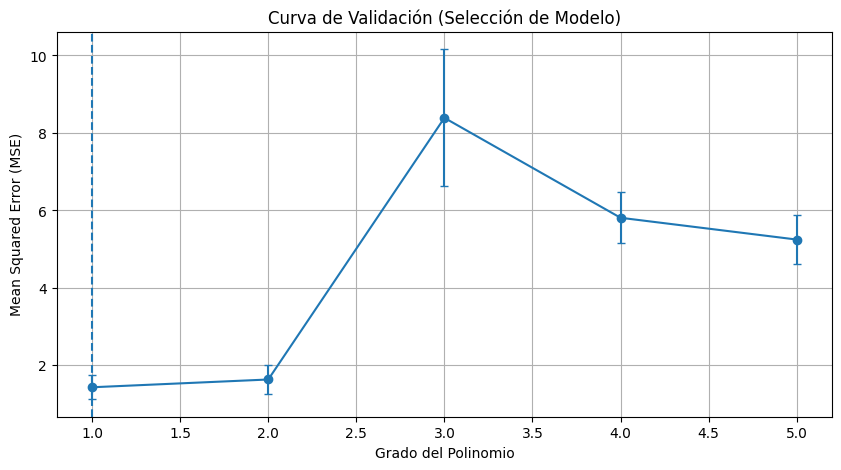

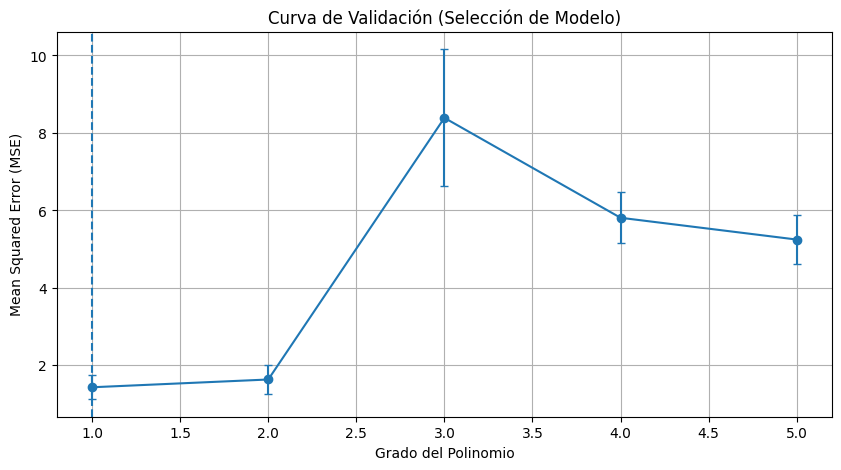

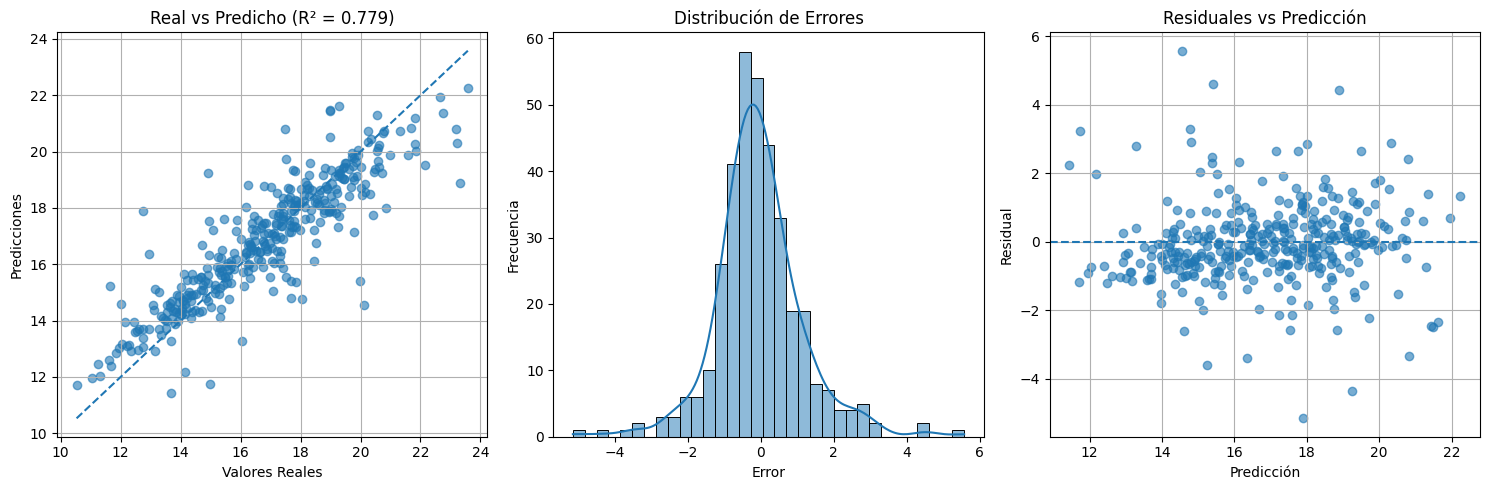

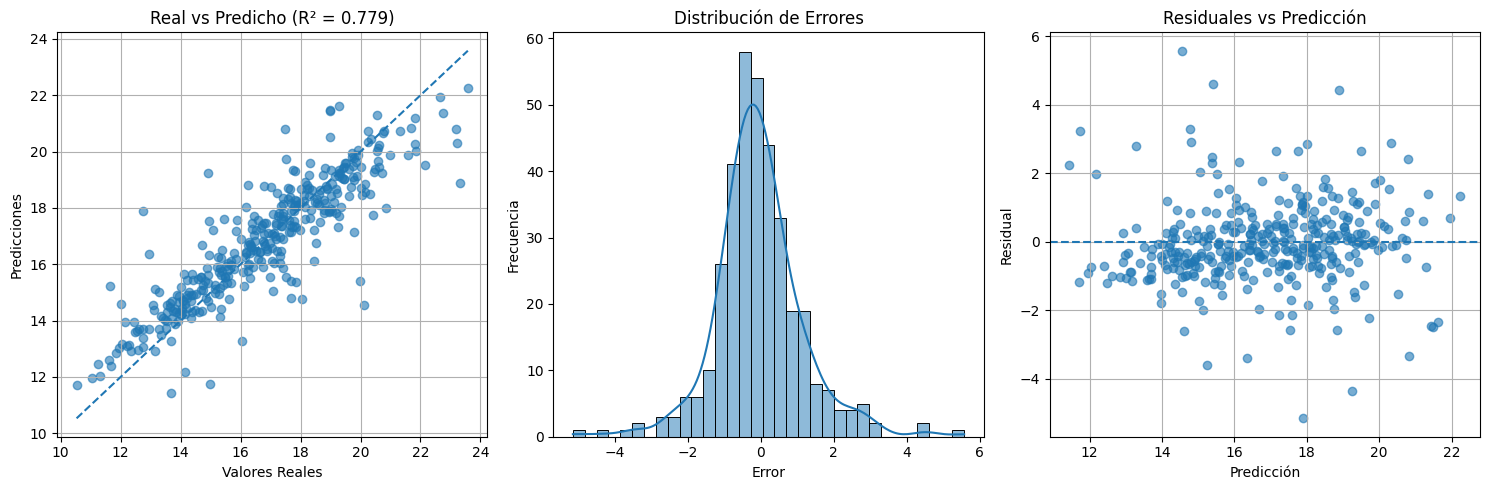


El modelo muestra buen ajuste global, con errores centrados en cero y
sin patrones claros en los residuales, indicando buena generalización.


In [42]:
# ==============================================================================
# 5. VISUALIZACIÓN DE RESULTADOS (VERSIÓN MULTIVARIABLE)
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# ======================================================
# 1. REAL VS PREDICHO
# ======================================================
plt.subplot(1, 3, 1)

plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")

plt.title(f"Real vs Predicho (R² = {r2:.3f})")
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.grid(True)

# ======================================================
# 2. DISTRIBUCIÓN DE ERRORES
# ======================================================
plt.subplot(1, 3, 2)

errores = y_test - y_pred
sns.histplot(errores, kde=True)

plt.title("Distribución de Errores")
plt.xlabel("Error")
plt.ylabel("Frecuencia")

# ======================================================
# 3. RESIDUALES VS PREDICCIÓN
# ======================================================
plt.subplot(1, 3, 3)

plt.scatter(y_pred, errores, alpha=0.6)
plt.axhline(0, linestyle="--")

plt.title("Residuales vs Predicción")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nEl modelo muestra buen ajuste global, con errores centrados en cero y")
print("sin patrones claros en los residuales, indicando buena generalización.")

## 4. Modelo de Regresión Polinomial

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

pipe_poly = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures()),
    ("model", LinearRegression())
])

param_grid_poly = {
    "poly__degree": [1,2,3,4,5]
}

grid_poly = GridSearchCV(pipe_poly, param_grid_poly, cv=10, scoring="neg_mean_squared_error")
grid_poly.fit(X_train, y_train)

best_poly = grid_poly.best_estimator_

y_pred = best_poly.predict(X_test)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred))
mae_poly = mean_absolute_error(y_test, y_pred)
r2_poly = r2_score(y_test, y_pred)

print(rmse_poly, mae_poly, r2_poly)

1.2047387016088476 0.8507954280105819 0.7787801806789469


In [52]:
degrees = range(1,5)
means = []
stds = []

from sklearn.model_selection import cross_val_score

for d in degrees:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=d)),
        ("model", LinearRegression())
    ])
    
    scores = cross_val_score(pipe, X_train, y_train, cv=10, scoring="neg_mean_squared_error")
    scores = -scores
    means.append(scores.mean())
    stds.append(scores.std())

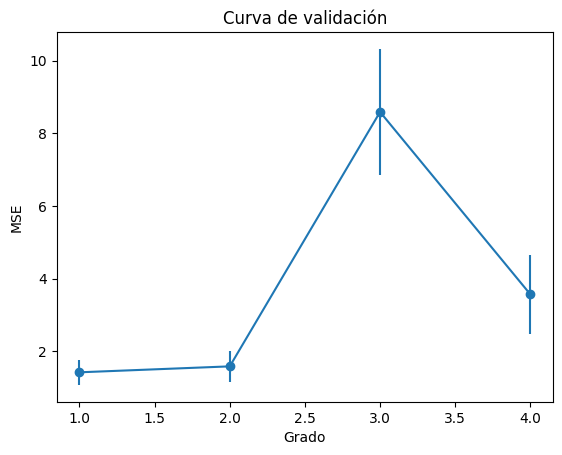

In [53]:
import matplotlib.pyplot as plt

plt.errorbar(degrees, means, yerr=stds, marker="o")
plt.title("Curva de validación")
plt.xlabel("Grado")
plt.ylabel("MSE")
plt.show()

## 5. Modelos Regularizados (Ridge y Lasso)

In [54]:
from sklearn.linear_model import Ridge, Lasso

models = {
    "Ridge": Ridge(),
    "Lasso": Lasso(max_iter=5000)
}

results = {}

for name, model in models.items():
    
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    
    grid = GridSearchCV(
        pipe,
        {"model__alpha": [0.01, 0.1, 1, 10]},
        cv=10,
        scoring="neg_mean_squared_error"
    )
    
    grid.fit(X_train, y_train)
    best = grid.best_estimator_
    
    y_pred = best.predict(X_test)
    
    results[name] = {
        "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
        "r2": r2_score(y_test, y_pred),
        "mae": mean_absolute_error(y_test, y_pred),
        "model": best
    }


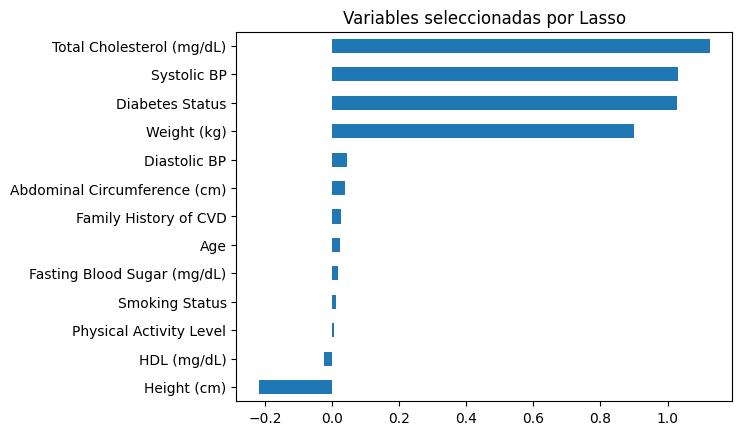

In [55]:
lasso_model = results["Lasso"]["model"]
coef = lasso_model.named_steps["model"].coef_

important = pd.Series(coef, index=X.columns)
important = important[important != 0]

important.sort_values().plot.barh(title="Variables seleccionadas por Lasso")
plt.show()

## 6. Modelo Polinomial Regularizado

In [56]:
pipe_poly_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures()),
    ("model", Ridge())
])

grid_poly_ridge = GridSearchCV(
    pipe_poly_ridge,
    {
        "poly__degree": [1,2,3],
        "model__alpha": [0.1, 1, 10]
    },
    cv=10,
    scoring="neg_mean_squared_error"
)

grid_poly_ridge.fit(X_train, y_train)
best_poly_ridge = grid_poly_ridge.best_estimator_

In [57]:
rows = []

def evaluate(model, name):
    y_pred = model.predict(X_test)
    rows.append([
        name,
        np.sqrt(mean_squared_error(y_test, y_pred)),
        mean_absolute_error(y_test, y_pred),
        r2_score(y_test, y_pred)
    ])

evaluate(best_poly, "Polynomial")
evaluate(results["Ridge"]["model"], "Ridge")
evaluate(results["Lasso"]["model"], "Lasso")
evaluate(best_poly_ridge, "Poly + Ridge")

tabla = pd.DataFrame(rows, columns=["Modelo", "RMSE", "MAE", "R2"])
tabla.sort_values("RMSE")

,Modelo,RMSE,MAE,R2
0,Polynomial,1.204739,0.850795,0.778780
2,Lasso,1.204847,0.855277,0.778740
1,Ridge,1.204923,0.851363,0.778713
3,Poly + Ridge,1.204923,0.851363,0.778713


## 7. Intervalos de Confianza (Bootstrapping)


## 8. Uso de Herramientas de IA Generativa

**Herramienta utilizada:** ChatGPT  

**Tipo de uso:**  
- Apoyo conceptual  
- Generación inicial de estructura  
- Explicación de regularización y bootstrapping  

**Prompts utilizados:**  
- "Explícame la diferencia entre Ridge y Lasso"  
- "Cómo implementar bootstrapping en sklearn"  

**Análisis crítico y aportes propios:**  
(Completar por los estudiantes)
